In [5]:
import kagglehub
import re
import time
import pandas as pd
import lyricsgenius
from tqdm import tqdm
from langdetect import detect, LangDetectException

# Download latest version
path = kagglehub.dataset_download("asaniczka/top-spotify-songs-in-73-countries-daily-updated")

print("Path to dataset files:", path)

Path to dataset files: /Users/yaz/.cache/kagglehub/datasets/asaniczka/top-spotify-songs-in-73-countries-daily-updated/versions/608


In [6]:
import os

path = "/Users/yaz/.cache/kagglehub/datasets/asaniczka/top-spotify-songs-in-73-countries-daily-updated/versions/608"

os.listdir(path)

['universal_top_spotify_songs.csv']

In [7]:
import pandas as pd

file = os.path.join(path, "universal_top_spotify_songs.csv")

df = pd.read_csv(file)

df.head()
df.columns

Index(['spotify_id', 'name', 'artists', 'daily_rank', 'daily_movement',
       'weekly_movement', 'country', 'snapshot_date', 'popularity',
       'is_explicit', 'duration_ms', 'album_name', 'album_release_date',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'time_signature'],
      dtype='str')

In [8]:
df.country.value_counts()

country
DO    29176
IT    29174
NI    29170
PL    29164
HU    29163
      ...  
VN    28406
UY    28403
LU    28315
VE    28263
GB    20919
Name: count, Length: 72, dtype: int64

## Filtering USA

In [9]:
import pandas as pd

# Ensure date format
df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])

# Filter USA only
df_us = df[df['country'] == 'US'].copy()

# Count number of days each song stayed in Top 50
days_top50 = (
    df_us
    .groupby('spotify_id')['snapshot_date']
    .nunique()
    .reset_index()
    .rename(columns={'snapshot_date': 'days_in_top50'})
)

# Song metadata (one row per song)
songs = (
    df_us
    .sort_values('snapshot_date')
    .drop_duplicates('spotify_id')
    [['spotify_id','name','artists','album_name','album_release_date']]
)

songs = songs.merge(days_top50, on='spotify_id')

## Downloading Lyrics 

In [10]:
songs.info()

<class 'pandas.DataFrame'>
RangeIndex: 1060 entries, 0 to 1059
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   spotify_id          1060 non-null   str  
 1   name                1060 non-null   str  
 2   artists             1060 non-null   str  
 3   album_name          1056 non-null   str  
 4   album_release_date  1056 non-null   str  
 5   days_in_top50       1060 non-null   int64
dtypes: int64(1), str(5)
memory usage: 49.8 KB


In [11]:
GENIUS_TOKEN = "uqc88KLVXvegbiOVn_3WLoUPh_D92wtFexnaln0MxRCKkyfsc4sIJHH6gS3gWQR6"

In [12]:
import lyricsgenius
import time
import re
import pandas as pd
from langdetect import detect, LangDetectException

genius = lyricsgenius.Genius(
    GENIUS_TOKEN,
    skip_non_songs=True,
    timeout=10,
    retries=1           # ← evita travar em retries infinitos
)
genius.verbose = False

# ─── funções auxiliares ─────────────────────────────────────────

def is_translated_title(title):
    """Retorna True se o título parece ser uma tradução"""
    patterns = [r'\(tradução\)', r'\(traducción\)', r'\(translation\)', r'\(letra\)', r'\(lyrics\)']
    for p in patterns:
        if re.search(p, title, re.IGNORECASE):
            return True
    return False

def clean_for_search(title, artist):
    """Remove (feat. ...) do título e usa só o primeiro artista"""
    title_clean = re.sub(r'\(feat\.?[^)]*\)', '', title, flags=re.IGNORECASE).strip()
    artist_clean = artist.split(',')[0].strip()
    return title_clean, artist_clean

def title_matches(query_title, result_title, threshold=0.5):
    """Verifica se o título do resultado bate minimamente com o que foi buscado"""
    query_words = set(re.sub(r'[^\w\s]', '', query_title.lower()).split())
    result_words = set(re.sub(r'[^\w\s]', '', result_title.lower()).split())
    if not query_words:
        return False
    return len(query_words & result_words) / len(query_words) >= threshold

def get_lyrics(title, artist):
    title_clean, artist_clean = clean_for_search(title, artist)
    query = f"{title_clean} {artist_clean}"
    print(f"\n  🔍 Buscando: '{query}'")

    try:
        results = genius.search_songs(query)
        hits = results.get("hits", [])
        print(f"  📋 Hits encontrados: {len(hits)}")

        if not hits:
            print("  ❌ Nenhum hit retornado pela API")
            return None

        for i, hit in enumerate(hits[:5]):
            song_title = hit["result"]["title"]
            song_artist = hit["result"]["primary_artist"]["name"]
            song_id = hit["result"]["id"]
            print(f"  [{i}] '{song_title}' by '{song_artist}' (id={song_id})")

            if is_translated_title(song_title):
                print("      ⚠️  Pulando: título parece ser tradução")
                continue

            if not title_matches(title_clean, song_title):
                print(f"      ⚠️  Pulando: título não bate (buscou '{title_clean}')")
                continue

            print(f"      ✅ Buscando letra (song_id={song_id})...")
            s = genius.search_song(song_id=song_id)

            if s and s.lyrics:
                print(f"      🎵 Letra encontrada! ({len(s.lyrics)} chars)")
                return s.lyrics
            else:
                print(f"      ❌ search_song retornou vazio")

        print("  ⛔ Todos os hits falharam ou foram pulados")
        return None

    except Exception as e:
        print(f"  💥 ERRO: {type(e).__name__}: {e}")
        return None

# ─── teste com 5 músicas ────────────────────────────────────────
test_songs = songs.head(20)
lyrics_list = []
failed_songs = []

for i, row in test_songs.iterrows():
    title = row['name']
    artist = row['artists']
    print(f"\n{'='*60}")
    print(f"🎤 [{i}] {title} — {artist}")

    lyrics = get_lyrics(title, artist)

    if lyrics is None:
        print("  ➡️  FALHOU: adicionando à lista de falhas")
        failed_songs.append({
            "spotify_id": row['spotify_id'],
            "title": title,
            "artist": artist
        })
    else:
        print("  ➡️  SUCESSO")

    lyrics_list.append({
        'spotify_id': row['spotify_id'],
        'lyrics': lyrics
    })

    time.sleep(0.5)

print(f"\n{'='*60}")
print(f"✅ Sucesso: {sum(1 for l in lyrics_list if l['lyrics'])}/{len(lyrics_list)}")
print(f"❌ Falhas:  {len(failed_songs)}")
if failed_songs:
    print("\nMúsicas que falharam:")
    for f in failed_songs:
        print(f"  - {f['title']} by {f['artist']}")



🎤 [0] Dark Red — Steve Lacy

  🔍 Buscando: 'Dark Red Steve Lacy'
  📋 Hits encontrados: 10
  [0] 'Dark Red' by 'Steve Lacy' (id=2996381)
      ✅ Buscando letra (song_id=2996381)...
      🎵 Letra encontrada! (1270 chars)
  ➡️  SUCESSO

🎤 [1] 500lbs — Lil Tecca

  🔍 Buscando: '500lbs Lil Tecca'
  📋 Hits encontrados: 3
  [0] '500lbs' by 'Lil Tecca' (id=9297203)
      ✅ Buscando letra (song_id=9297203)...
      🎵 Letra encontrada! (2488 chars)
  ➡️  SUCESSO

🎤 [2] Rich Baby Daddy (feat. Sexyy Red & SZA) — Drake, Sexyy Red, SZA

  🔍 Buscando: 'Rich Baby Daddy Drake'
  📋 Hits encontrados: 10
  [0] 'Rich Baby Daddy' by 'Drake' (id=9592330)
      ✅ Buscando letra (song_id=9592330)...
      🎵 Letra encontrada! (4330 chars)
  ➡️  SUCESSO

🎤 [3] Slime You Out (feat. SZA) — Drake, SZA

  🔍 Buscando: 'Slime You Out Drake'
  📋 Hits encontrados: 10
  [0] 'Slime You Out' by 'Drake' (id=9521954)
      ✅ Buscando letra (song_id=9521954)...
      🎵 Letra encontrada! (3765 chars)
  ➡️  SUCESSO

🎤 [4] Stra

## Em produção 

In [13]:
import lyricsgenius
import time
import re
import random
import pandas as pd
from tqdm import tqdm
from langdetect import detect, LangDetectException

genius = lyricsgenius.Genius(
    GENIUS_TOKEN,
    skip_non_songs=True,
    timeout=10,
    retries=1
)
genius.verbose = False

# ─── funções auxiliares ─────────────────────────────────────────

def is_translated_title(title):
    patterns = [r'\(tradução\)', r'\(traducción\)', r'\(translation\)', r'\(letra\)', r'\(lyrics\)']
    return any(re.search(p, title, re.IGNORECASE) for p in patterns)

def clean_for_search(title, artist):
    title_clean = re.sub(r'\(feat\.?[^)]*\)', '', title, flags=re.IGNORECASE).strip()
    artist_clean = artist.split(',')[0].strip()
    return title_clean, artist_clean

def title_matches(query_title, result_title, threshold=0.5):
    query_words = set(re.sub(r'[^\w\s]', '', query_title.lower()).split())
    result_words = set(re.sub(r'[^\w\s]', '', result_title.lower()).split())
    if not query_words:
        return False
    return len(query_words & result_words) / len(query_words) >= threshold

def get_lyrics(title, artist, verbose=False):
    title_clean, artist_clean = clean_for_search(title, artist)
    query = f"{title_clean} {artist_clean}"
    if verbose:
        print(f"\n  🔍 Query: '{query}'")
    try:
        results = genius.search_songs(query)
        hits = results.get("hits", [])
        if verbose:
            print(f"  📋 Hits: {len(hits)}")
        if not hits:
            if verbose: print("  ❌ Nenhum hit")
            return None
        for i, hit in enumerate(hits[:5]):
            song_title = hit["result"]["title"]
            song_artist = hit["result"]["primary_artist"]["name"]
            song_id = hit["result"]["id"]
            if verbose:
                print(f"  [{i}] '{song_title}' — '{song_artist}'")
            if is_translated_title(song_title):
                if verbose: print("      ⚠️  tradução, pulando")
                continue
            if not title_matches(title_clean, song_title):
                if verbose: print(f"      ⚠️  título não bate, pulando")
                continue
            s = genius.search_song(song_id=song_id)
            if s and s.lyrics:
                if verbose: print(f"      🎵 OK ({len(s.lyrics)} chars)")
                return s.lyrics
            if verbose: print("      ❌ sem letra")
        if verbose: print("  ⛔ Todos os hits falharam")
        return None
    except Exception as e:
        if verbose: print(f"  💥 {type(e).__name__}: {e}")
        return None

# ─── produção: todas as músicas ─────────────────────────────────

lyrics_list = []
failed_songs = []

for i, row in tqdm(songs.iterrows(), total=len(songs), desc="Baixando letras"):
    title = row['name']
    artist = row['artists']

    lyrics = get_lyrics(title, artist, verbose=False)

    if lyrics is None:
        failed_songs.append({
            "spotify_id": row['spotify_id'],
            "title": title,
            "artist": artist
        })

    lyrics_list.append({
        'spotify_id': row['spotify_id'],
        'lyrics': lyrics
    })

    time.sleep(0.5)

lyrics_df = pd.DataFrame(lyrics_list)
failed_df = pd.DataFrame(failed_songs)

print(f"\n✅ Sucesso: {lyrics_df['lyrics'].notna().sum()}/{len(lyrics_df)}")
print(f"❌ Falhas:  {len(failed_df)}")

# ─── sanity check: 10% aleatório ────────────────────────────────

print(f"\n{'='*60}")
print("🔎 SANITY CHECK — 10% aleatório")
print('='*60)

sample = songs.sample(frac=0.1, random_state=42)

sanity_ok = 0
sanity_fail = 0

for i, row in sample.iterrows():
    title = row['name']
    artist = row['artists']
    print(f"\n🎤 {title} — {artist}")

    lyrics = get_lyrics(title, artist, verbose=True)

    if lyrics:
        sanity_ok += 1
        print("  ➡️  SUCESSO")
    else:
        sanity_fail += 1
        print("  ➡️  FALHOU")

    time.sleep(0.05)

print(f"\n{'='*60}")
print(f"Sanity Check — ✅ {sanity_ok}  ❌ {sanity_fail}  de {len(sample)} músicas")

Baixando letras:  15%|█▍        | 158/1060 [10:26<59:34,  3.96s/it]  


KeyboardInterrupt: 

Merging lyrics with df music

In [ ]:
#os.mkdir("data")
#lyrics_df.to_csv("data/lyrics_11_03.csv", index=False)



In [ ]:
final_df = songs.merge(lyrics_df, on='spotify_id', how='left')
#final_df.to_csv("data/final_df.csv", index=False)


In [ ]:
import pandas as pd
import os

# ── 1. Carregar o dataset do Spotify ───────────────────────────
path = "/Users/felipe/.cache/kagglehub/datasets/asaniczka/top-spotify-songs-in-73-countries-daily-updated/versions/608"
df = pd.read_csv(os.path.join(path, "universal_top_spotify_songs.csv"))
df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])

# ── 2. Filtrar USA ─────────────────────────────────────────────
df_us = df[df['country'] == 'US'].copy()
max_date = df_us['snapshot_date'].max()

# ── 3. Calcular entry/exit/days por música ─────────────────────
song_stats = (
    df_us.groupby('spotify_id')['snapshot_date']
    .agg(entry_date='min', exit_date='max')
    .reset_index()
)
song_stats['days_in_top50'] = (song_stats['exit_date'] - song_stats['entry_date']).dt.days + 1

# Só músicas com ≥100 dias de janela de observação
song_stats = song_stats[(max_date - song_stats['entry_date']).dt.days >= 100]

# ── 4. Metadados + audio features (1 linha por música) ────────
meta_cols = [
    'spotify_id', 'name', 'artists', 'album_name', 'album_release_date',
    'danceability', 'energy', 'valence', 'tempo',
    'loudness', 'speechiness', 'acousticness', 'instrumentalness'
]
song_meta = (
    df_us.sort_values('snapshot_date')
    .drop_duplicates('spotify_id')[meta_cols]
)

songs = song_meta.merge(song_stats, on='spotify_id')

# ── 5. Carregar letras já baixadas e fazer merge ───────────────
lyrics_df = pd.read_csv("data/lyrics_11_03.csv")

final_df = songs.merge(lyrics_df, on='spotify_id', how='left')

print(f"Total músicas (≥100 dias): {len(final_df)}")
print(f"Com letra:    {final_df['lyrics'].notna().sum()}")
print(f"Sem letra:    {final_df['lyrics'].isna().sum()}")
print(final_df[['name', 'artists', 'entry_date', 'exit_date', 'days_in_top50', 'danceability', 'lyrics']].head())


Total músicas (≥100 dias): 907
Com letra:    851
Sem letra:    56
                                      name                artists entry_date  \
0                                 Dark Red             Steve Lacy 2023-10-18   
1                                   500lbs              Lil Tecca 2023-10-18   
2  Rich Baby Daddy (feat. Sexyy Red & SZA)  Drake, Sexyy Red, SZA 2023-10-18   
3                Slime You Out (feat. SZA)             Drake, SZA 2023-10-18   
4                                Strangers            Kenya Grace 2023-10-18   

   exit_date  days_in_top50  danceability  \
0 2024-01-11             86         0.603   
1 2024-04-19            185         0.722   
2 2024-03-29            164         0.645   
3 2023-10-28             11         0.483   
4 2024-01-13             88         0.628   

                                              lyrics  
0  [Verse 1]\nSomething bad is 'bout to happen to...  
1  [Intro]\nUh\nUh-uh, uh (Blatt)\nUh-uh, uh\nUh-...  
2  [Part I]\n\n[I

In [ ]:
final_df.days_in_top50.describe()
final_df[final_df.days_in_top50 >600]

,spotify_id,name,artists,album_name,album_release_date,danceability,energy,valence,tempo,loudness,speechiness,acousticness,instrumentalness,entry_date,exit_date,days_in_top50,lyrics
19,4KULAymBBJcPRpk1yO4dOG,I Remember Everything (feat. Kacey Musgraves),"Zach Bryan, Kacey Musgraves",Zach Bryan,2023-08-25,0.429,0.453,0.155,77.639,-7.746,0.0459,0.5540,0.000002,2023-10-18,2025-06-11,603,[Verse 1: Zach Bryan]\nRotgut whiskey's gonna ...
43,7KA4W4McWYRpgf0fWsJZWB,See You Again (feat. Kali Uchis),"Tyler, The Creator, Kali Uchis",Flower Boy,2017-07-21,0.558,0.559,0.620,78.558,-9.222,0.0959,0.3710,0.000007,2023-10-18,2025-06-11,603,"[Intro: Tyler, The Creator]\nOkay, okay, okay,..."
50,0ofHAoxe9vBkTCp2UQIavz,Dreams - 2004 Remaster,Fleetwood Mac,Rumours (Super Deluxe),1977-02-04,0.828,0.492,0.789,120.151,-9.744,0.0276,0.0644,0.004280,2023-10-20,2025-06-11,601,NaN


<Axes: >

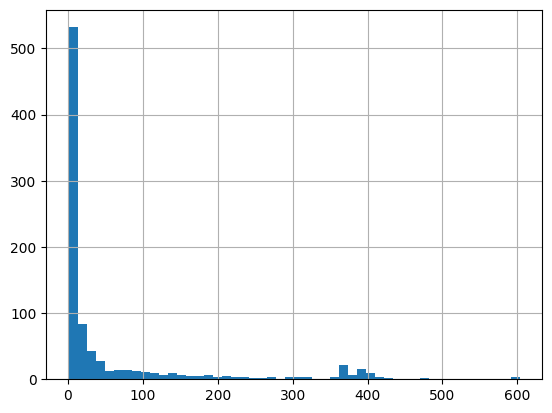

In [ ]:
from matplotlib import pyplot as plt
final_df.days_in_top50.hist(bins=50)

# comparar numero de musicas a partir da data de entrada da musica (só considerar musicas que entraram no top50 e tentemos 100 dias de historico) 
# Data de entrada = data em que a musica entrou no top50
# Data de saida = data em que a musica saiu do top50
# Numero de dias no top50 = data de saida - data de entrada
# Data de Lancamento da cancao = data em que a musica foi lancada 

